# imports

In [7]:
!pip install -q matplotlib
!pip install -q umap-learn

In [2]:
%reload_ext autoreload
%autoreload 2

import torch
import sys
import os
from torchmetrics.functional.pairwise import pairwise_cosine_similarity
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt

# local imports
sys.path.insert(
    0,
    os.path.join(
        (os.path.dirname(os.path.abspath(''))),
    )
)
from evaluation.bright.retrievers import (
    get_scores,
    calculate_retrieval_metrics
)
sys.path.pop(0)


PKLS_PATH = os.path.join(os.path.dirname(os.path.abspath('')), 'evaluation', 'bright')
SEPARATION_ID = 45

/home/oh/arubinstein17/github/ReasonIR/envs/reasonir/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# functions

In [55]:
def plot_val_vs_training_examples(val_list, name, constant_val=None, constant_label=None):
    plt.figure(figsize=(10,6))
    plt.plot(range(len(val_list))[::-1], val_list)
    plt.xlabel('Number of Training Examples')
    plt.ylabel(name)
    plt.title(f'{name} vs Number of Training Examples')
    plt.grid(True)
    if constant_val is not None:
        if constant_label is not None:
            label = constant_label
        else:
            label = 'Constant Value'
        plt.axhline(y=constant_val, color='red', linestyle='--', label=label)
    plt.legend()
    plt.show()


def compute_results(
    query_emb,
    doc_emb,
    documents,
    ground_truth,
    query_ids,
    doc_ids,
    excluded_ids,
    separation_id=None,
    projection_matrix=None
):
    if separation_id is not None:
        query_emb = query_emb[:separation_id]
        query_ids = query_ids[:separation_id]

    if projection_matrix is not None:
        query_emb = query_emb @ projection_matrix

    scores = pairwise_cosine_similarity(torch.from_numpy(query_emb), torch.from_numpy(doc_emb))
    scores = scores.tolist()
    assert len(scores) == len(query_ids), f"{len(scores)}, {len(query_ids)}"
    assert len(scores[0]) == len(documents), f"{len(scores[0])}, {len(documents)}"
    final_scores = get_scores(query_ids=query_ids,doc_ids=doc_ids,scores=scores,excluded_ids=excluded_ids)
    results = calculate_retrieval_metrics(results=final_scores, qrels=ground_truth)
    # print(results)
    return results


def least_squares_projection(X, Y):
    """
    Perform least squares projection of Y onto X
    """
    # Ensure X and Y are numpy arrays
    # Get training data from indices after SEPARATION_ID

    # Solve for projection matrix using least squares
    # X @ W = Y
    # W = (X^T X)^-1 X^T Y
    W = np.linalg.lstsq(X, Y, rcond=None)[0]

    print_distances(X, Y, W)

    return W

def print_distances(X, Y, W, name=None):
    # print(W.shape)  # Should be (base_dim, reason_dim)
    # Print distances between original and projected vectors
    projected_X = X @ W
    distances = np.linalg.norm(Y - projected_X, axis=1)
    if name is not None:
        print(f"Distances for {name}:")
    mean_d = np.mean(distances)
    max_d = np.max(distances)
    min_d = np.min(distances)
    print("Mean distance:", mean_d)
    print("Max distance:", max_d)
    print("Min distance:", min_d)
    return mean_d, max_d, min_d

def print_relevant_docs(idx, query_ids, ground_truth, documents):
    for relevant_doc in ground_truth[query_ids[idx]]:
        print(documents[int(relevant_doc)])


# reproduce numbers

In [4]:
doc_ids, query_ids, excluded_ids = torch.load(os.path.join(PKLS_PATH, 'ids.pkl'))
documents, doc_emb = torch.load(os.path.join(PKLS_PATH, 'base_doc_emb.pkl'))
queries_base, query_emb_base = torch.load(os.path.join(PKLS_PATH, 'base_emb.pkl'))
queries_reason, query_emb_reason = torch.load(os.path.join(PKLS_PATH, 'reason_emb.pkl'))
ground_truth = torch.load(os.path.join(PKLS_PATH, 'ground_truth.pkl'))

In [ ]:
results_base = compute_results(
    query_emb=query_emb_base,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids
)

{'NDCG@1': 0.19737, 'NDCG@5': 0.25338, 'NDCG@10': 0.27224, 'NDCG@25': 0.29811, 'NDCG@50': 0.31211, 'NDCG@100': 0.33633, 'MAP@1': 0.10746, 'MAP@5': 0.21089, 'MAP@10': 0.22015, 'MAP@25': 0.22732, 'MAP@50': 0.22926, 'MAP@100': 0.23172, 'Recall@1': 0.10746, 'Recall@5': 0.30279, 'Recall@10': 0.35542, 'Recall@25': 0.45849, 'Recall@50': 0.5177, 'Recall@100': 0.6391, 'P@1': 0.19737, 'P@5': 0.11579, 'P@10': 0.06711, 'P@25': 0.03211, 'P@50': 0.01868, 'P@100': 0.01197, 'MRR': 0.29551, 'Oracle NDCG@1': 0.77632, 'Oracle NDCG@5': 0.67497, 'Oracle NDCG@10': 0.6728, 'Oracle NDCG@25': 0.67467, 'Oracle NDCG@50': 0.67467, 'Oracle NDCG@100': 0.67909}


In [49]:
results_base_short = compute_results(
    query_emb=query_emb_base,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids,
    separation_id=SEPARATION_ID
)

{'NDCG@1': 0.22222, 'NDCG@5': 0.26337, 'NDCG@10': 0.28566, 'NDCG@25': 0.32147, 'NDCG@50': 0.33993, 'NDCG@100': 0.36304, 'MAP@1': 0.12593, 'MAP@5': 0.22481, 'MAP@10': 0.23499, 'MAP@25': 0.24538, 'MAP@50': 0.24778, 'MAP@100': 0.25015, 'Recall@1': 0.12593, 'Recall@5': 0.30741, 'Recall@10': 0.37037, 'Recall@25': 0.51481, 'Recall@50': 0.59259, 'Recall@100': 0.70741, 'P@1': 0.22222, 'P@5': 0.10667, 'P@10': 0.06222, 'P@25': 0.032, 'P@50': 0.01956, 'P@100': 0.01244, 'MRR': 0.31505, 'Oracle NDCG@1': 0.82222, 'Oracle NDCG@5': 0.73886, 'Oracle NDCG@10': 0.73886, 'Oracle NDCG@25': 0.74201, 'Oracle NDCG@50': 0.74201, 'Oracle NDCG@100': 0.74799}


In [ ]:
results_reason = compute_results(
    query_emb=query_emb_reason,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids
)

{'NDCG@1': 0.31579, 'NDCG@5': 0.34635, 'NDCG@10': 0.36869, 'NDCG@25': 0.39197, 'NDCG@50': 0.41933, 'NDCG@100': 0.42691, 'MAP@1': 0.18061, 'MAP@5': 0.30298, 'MAP@10': 0.31194, 'MAP@25': 0.31989, 'MAP@50': 0.32471, 'MAP@100': 0.3256, 'Recall@1': 0.18061, 'Recall@5': 0.38941, 'Recall@10': 0.46178, 'Recall@25': 0.54151, 'Recall@50': 0.65962, 'Recall@100': 0.6969, 'P@1': 0.31579, 'P@5': 0.15, 'P@10': 0.08553, 'P@25': 0.04053, 'P@50': 0.025, 'P@100': 0.01329, 'MRR': 0.39604, 'Oracle NDCG@1': 0.82895, 'Oracle NDCG@5': 0.73188, 'Oracle NDCG@10': 0.72938, 'Oracle NDCG@25': 0.73255, 'Oracle NDCG@50': 0.73485, 'Oracle NDCG@100': 0.73485}


In [50]:
results_reason_short = compute_results(
    query_emb=query_emb_reason,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids,
    separation_id=SEPARATION_ID
)

{'NDCG@1': 0.26667, 'NDCG@5': 0.3224, 'NDCG@10': 0.34592, 'NDCG@25': 0.37794, 'NDCG@50': 0.40355, 'NDCG@100': 0.41251, 'MAP@1': 0.15741, 'MAP@5': 0.27231, 'MAP@10': 0.28071, 'MAP@25': 0.29198, 'MAP@50': 0.296, 'MAP@100': 0.29692, 'Recall@1': 0.15741, 'Recall@5': 0.39074, 'Recall@10': 0.46481, 'Recall@25': 0.57778, 'Recall@50': 0.68704, 'Recall@100': 0.73333, 'P@1': 0.26667, 'P@5': 0.13778, 'P@10': 0.07778, 'P@25': 0.03911, 'P@50': 0.024, 'P@100': 0.01289, 'MRR': 0.37065, 'Oracle NDCG@1': 0.84444, 'Oracle NDCG@5': 0.76382, 'Oracle NDCG@10': 0.76382, 'Oracle NDCG@25': 0.76917, 'Oracle NDCG@50': 0.77305, 'Oracle NDCG@100': 0.77305}


# Check dimensioinality reduction

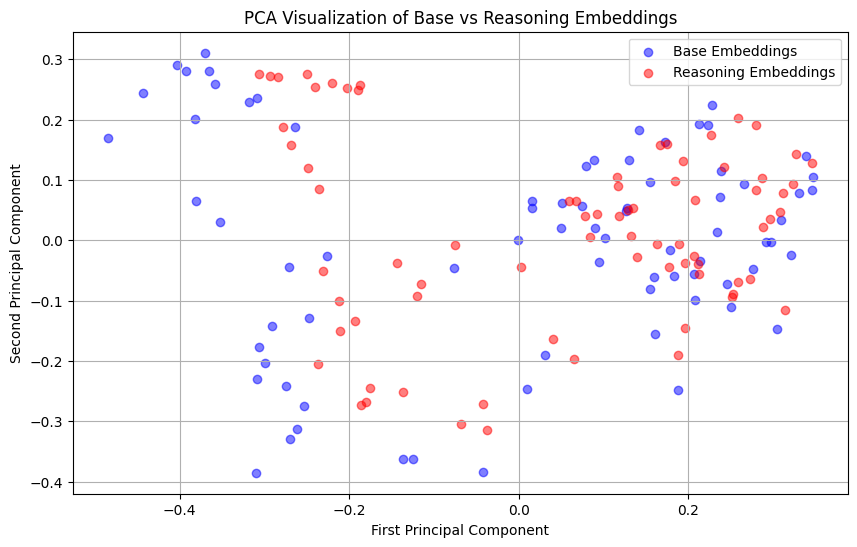

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality to 2D using PCA
pca = PCA(n_components=2)
query_base_2d = pca.fit_transform(query_emb_base)
query_reason_2d = pca.transform(query_emb_reason)

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(query_base_2d[:,0], query_base_2d[:,1], c='blue', alpha=0.5, label='Base Embeddings')
plt.scatter(query_reason_2d[:,0], query_reason_2d[:,1], c='red', alpha=0.5, label='Reasoning Embeddings')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Visualization of Base vs Reasoning Embeddings')
plt.legend()
plt.grid(True)
plt.show()


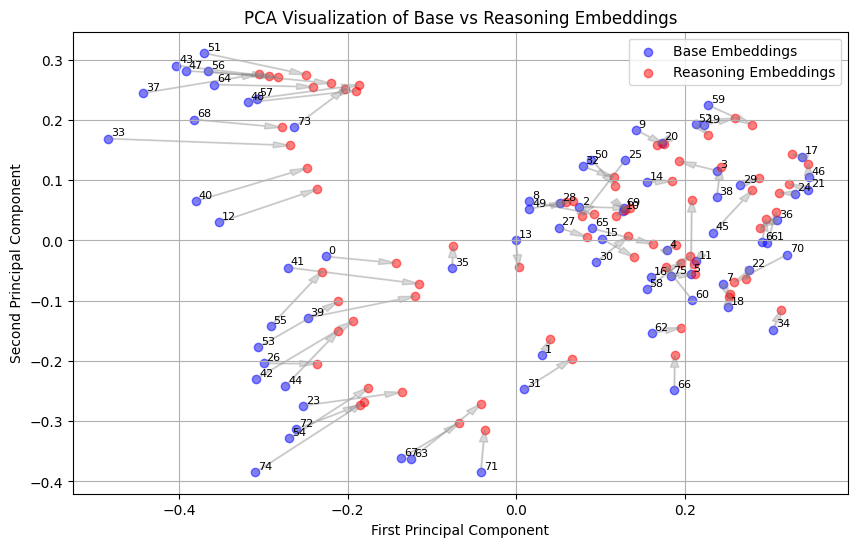

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality to 2D using PCA
pca = PCA(n_components=2)
query_base_2d = pca.fit_transform(query_emb_base)
query_reason_2d = pca.transform(query_emb_reason)

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(query_base_2d[:,0], query_base_2d[:,1], c='blue', alpha=0.5, label='Base Embeddings')
plt.scatter(query_reason_2d[:,0], query_reason_2d[:,1], c='red', alpha=0.5, label='Reasoning Embeddings')

# Draw arrows between corresponding embeddings
for i in range(len(query_base_2d)):
    plt.arrow(query_base_2d[i,0], query_base_2d[i,1],
             query_reason_2d[i,0] - query_base_2d[i,0],
             query_reason_2d[i,1] - query_base_2d[i,1],
             color='gray', alpha=0.3, head_width=0.01, head_length=0.02,
             length_includes_head=True)
    # Add small number labels near base embeddings
    plt.annotate(str(i), (query_base_2d[i,0], query_base_2d[i,1]),
                xytext=(2, 2), textcoords='offset points',
                fontsize=8)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Visualization of Base vs Reasoning Embeddings')
plt.legend()
plt.grid(True)
plt.show()


/home/oh/arubinstein17/github/ReasonIR/envs/reasonir/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/oh/arubinstein17/github/ReasonIR/envs/reasonir/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/oh/arubinstein17/github/ReasonIR/envs/reasonir/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


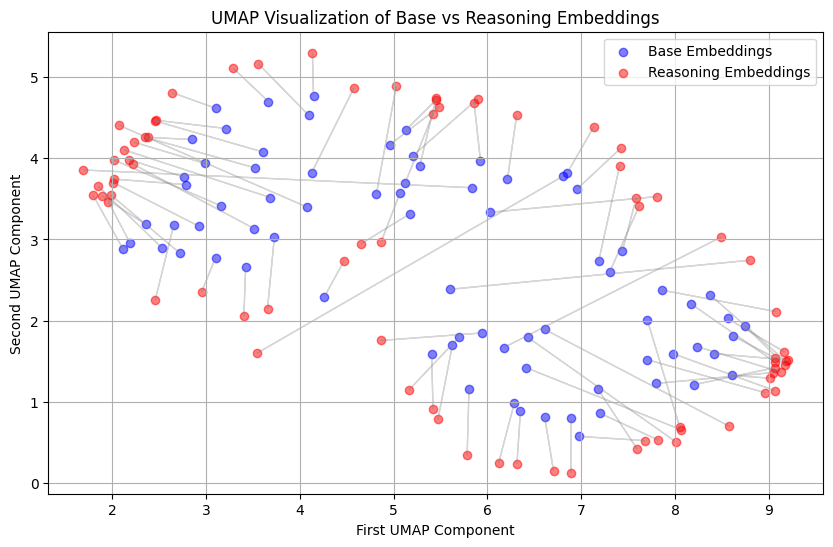

In [12]:
import umap.umap_ as umap

# Reduce dimensionality to 2D using UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
query_base_2d = reducer.fit_transform(query_emb_base)
query_reason_2d = reducer.transform(query_emb_reason)

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(query_base_2d[:,0], query_base_2d[:,1], c='blue', alpha=0.5, label='Base Embeddings')
plt.scatter(query_reason_2d[:,0], query_reason_2d[:,1], c='red', alpha=0.5, label='Reasoning Embeddings')

# Draw arrows between corresponding embeddings
for i in range(len(query_base_2d)):
    plt.arrow(query_base_2d[i,0], query_base_2d[i,1],
             query_reason_2d[i,0] - query_base_2d[i,0],
             query_reason_2d[i,1] - query_base_2d[i,1],
             color='gray', alpha=0.3, head_width=0.01, head_length=0.02,
             length_includes_head=True)

plt.xlabel('First UMAP Component')
plt.ylabel('Second UMAP Component')
plt.title('UMAP Visualization of Base vs Reasoning Embeddings')
plt.legend()
plt.grid(True)
plt.show()


# Look into specific examples

In [36]:

def print_query_comparison(idx, queries_base, queries_reason, query_emb_base, query_emb_reason):
    print(f"Query: {queries_base[idx]}")
    print("================")
    print(f"Query with reasoning: {queries_reason[idx]}")
    print("================")
    # Calculate cosine similarity between base and reasoning embeddings
    cosine_sim = np.dot(query_emb_base[idx], query_emb_reason[idx]) / (
        np.linalg.norm(query_emb_base[idx]) * np.linalg.norm(query_emb_reason[idx]))
    print(f"Cosine Similarity: {cosine_sim}")
    print("================")
    print("Relevant docs:")
    print_relevant_docs(idx, query_ids, ground_truth, documents)
    print("================")


## Distant after PCA

In [37]:
print_query_comparison(33, queries_base, queries_reason, query_emb_base, query_emb_reason)

Query: Imagine you're organizing a workshop and you have 10 enthusiastic participants. You want to split them into 3 different project teams for group activities. Each team must have at least one participant. In how many unique ways can you form these teams?
Query with reasoning: The essential problem here is to determine the number of unique ways to divide 10 participants into 3 distinct groups, where each group must contain at least one participant. This is a problem of partitioning a set into non-empty subsets, which is a common problem in combinatorial mathematics. Specifically, we are looking at a type of partitioning often related to the Stirling numbers of the second kind, which count the ways to partition a set of n objects into k non-empty subsets. However, since the groups are distinct (implying that the order of the groups matters), our approach needs to account for this distinction.

### Step-by-Step Reasoning:

1. **Understanding Stirling Numbers of the Second Kind**:
   -

In [38]:
print_query_comparison(68, queries_base, queries_reason, query_emb_base, query_emb_reason)

Query: Imagine you're organizing a display case for a toy store, and you have 4 unique superhero figurines, 3 unique dinosaur figurines, and 2 unique robot figurines. You want to select 4 figurines for the display, but you've promised a big superhero fan that at least 2 of the figurines will be superheroes. In how many different ways can you arrange the display under these conditions?
Query with reasoning: ### Essential Problem

The core challenge here is to calculate the number of ways to select 4 figurines for a display from a set of 9 unique figurines (4 superheroes, 3 dinosaurs, and 2 robots), with the constraint that at least 2 of the selected figurines must be superheroes.

### Step by Step Reasoning

1. **Understanding the Constraint**: The condition that at least 2 of the figurines must be superheroes is key. This means we can have either 2, 3, or all 4 figurines as superheroes in our selection.

2. **Breaking Down the Problem**: It's helpful to break this problem into three se

## Close after PCA

In [39]:
print_query_comparison(18, queries_base, queries_reason, query_emb_base, query_emb_reason)

Query: Imagine you're a magician who has created a spell that can change the temperature in any room to a specific degree, no matter where it is in the world. This is represented by f = u(z) + iv(z), an entire function in complex plane C. You've discovered that no matter how you cast this spell, the change in temperature you can achieve is always below a certain level, let's say 100 degrees Fahrenheit. I.e., the modulus of the function is bounded. If this spell works everywhere on Earth without fail, does this mean your spell can only ever achieve one specific temperature change, no matter where you use it or how — is the function constant?
Query with reasoning: To address the question, let's break down the problem into its mathematical and physical elements, applying principles of complex analysis.

1. **Identifying the Essential Problem**:
The essential problem can be framed as whether a bounded entire function (a complex function that is analytic and defined everywhere in the comple

In [40]:
print_query_comparison(34, queries_base, queries_reason, query_emb_base, query_emb_reason)

Query: Imagine you're programming a new video game that involves a magical landscape where the terrain's elevation at any point is determined by a formula based on the distance from a certain landmark. Specifically, the elevation is given by the square of the distance times the sine of the distance. You're tasked with creating a smooth path between two points on this landscape, both of which are exactly the same elevation, located 10pi and 11pi units away from the landmark, respectively. Is it guaranteed that there will be a point between these two locations where the path is perfectly flat, meaning the slope of the path is zero?
Query with reasoning: The essential problem here involves understanding the mathematical relationship between the distance from a landmark and the elevation of the terrain, and then applying this understanding to determine if there's a point between two specific distances where the slope of the path—essentially the derivative of the elevation formula with resp

# learn projections

In [54]:
Ws = []
for i in tqdm(range(SEPARATION_ID, query_emb_base.shape[0])):
    W = least_squares_projection(query_emb_base[i:], query_emb_reason[i:])
    mean_d, max_d, min_d = print_distances(query_emb_base[:SEPARATION_ID], query_emb_reason[:SEPARATION_ID], W, name="all")
    Ws.append((i, W, mean_d, max_d, min_d))



  3%|▎         | 1/31 [00:01<00:38,  1.27s/it]

Mean distance: 9.648606e-08
Max distance: 1.03036534e-07
Min distance: 9.240088e-08
Distances for all:
Mean distance: 0.7455483
Max distance: 0.927139
Min distance: 0.51266533


  6%|▋         | 2/31 [00:02<00:38,  1.33s/it]

Mean distance: 9.576423e-08
Max distance: 9.910413e-08
Min distance: 9.138276e-08
Distances for all:
Mean distance: 0.747205
Max distance: 0.9272388
Min distance: 0.51276004


 10%|▉         | 3/31 [00:03<00:36,  1.31s/it]

...

Mean distance: 9.314599e-08
Max distance: 9.4817615e-08
Min distance: 9.076541e-08
Distances for all:
Mean distance: 0.8598422
Max distance: 0.92684644
Min distance: 0.71035004


 97%|█████████▋| 30/31 [00:54<00:01,  1.99s/it]

Mean distance: 9.2487895e-08
Max distance: 9.304486e-08
Min distance: 9.1930936e-08
Distances for all:
Mean distance: 0.88610536
Max distance: 0.94534785
Min distance: 0.7202701


100%|██████████| 31/31 [00:56<00:00,  1.84s/it]

Mean distance: 3.2843857e-07
Max distance: 3.2843857e-07
Min distance: 3.2843857e-07
Distances for all:
Mean distance: 0.93013346
Max distance: 0.95524937
Min distance: 0.8291412


In [65]:
ndcgs_at_10 = []
mean_ds = []
res_without_proj = compute_results(
    query_emb=query_emb_base,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids,
    separation_id=SEPARATION_ID,
)['NDCG@10']
res_without_proj_reason = compute_results(
    query_emb=query_emb_reason,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids,
    separation_id=SEPARATION_ID,
)['NDCG@10']
for i, W, mean_d, max_d, min_d in Ws:
    print(f"Results for {query_emb_base.shape[0] - i} test embeddings:")
    results_base_short_with_proj = compute_results(
        query_emb=query_emb_base,
        doc_emb=doc_emb,
        documents=documents,
        ground_truth=ground_truth,
        query_ids=query_ids,
        doc_ids=doc_ids,
        excluded_ids=excluded_ids,
        separation_id=SEPARATION_ID,
        projection_matrix=W
    )
    ndcgs_at_10.append(results_base_short_with_proj['NDCG@10'])
    mean_ds.append(mean_d)

    # print(results_base_short_with_proj)
    print("\n")
ndcgs_at_10.append(res_without_proj)


{'NDCG@1': 0.22222, 'NDCG@5': 0.26337, 'NDCG@10': 0.28566, 'NDCG@25': 0.32147, 'NDCG@50': 0.33993, 'NDCG@100': 0.36304, 'MAP@1': 0.12593, 'MAP@5': 0.22481, 'MAP@10': 0.23499, 'MAP@25': 0.24538, 'MAP@50': 0.24778, 'MAP@100': 0.25015, 'Recall@1': 0.12593, 'Recall@5': 0.30741, 'Recall@10': 0.37037, 'Recall@25': 0.51481, 'Recall@50': 0.59259, 'Recall@100': 0.70741, 'P@1': 0.22222, 'P@5': 0.10667, 'P@10': 0.06222, 'P@25': 0.032, 'P@50': 0.01956, 'P@100': 0.01244, 'MRR': 0.31505, 'Oracle NDCG@1': 0.82222, 'Oracle NDCG@5': 0.73886, 'Oracle NDCG@10': 0.73886, 'Oracle NDCG@25': 0.74201, 'Oracle NDCG@50': 0.74201, 'Oracle NDCG@100': 0.74799}
{'NDCG@1': 0.26667, 'NDCG@5': 0.3224, 'NDCG@10': 0.34592, 'NDCG@25': 0.37794, 'NDCG@50': 0.40355, 'NDCG@100': 0.41251, 'MAP@1': 0.15741, 'MAP@5': 0.27231, 'MAP@10': 0.28071, 'MAP@25': 0.29198, 'MAP@50': 0.296, 'MAP@100': 0.29692, 'Recall@1': 0.15741, 'Recall@5': 0.39074, 'Recall@10': 0.46481, 'Recall@25': 0.57778, 'Recall@50': 0.68704, 'Recall@100': 0.73333,

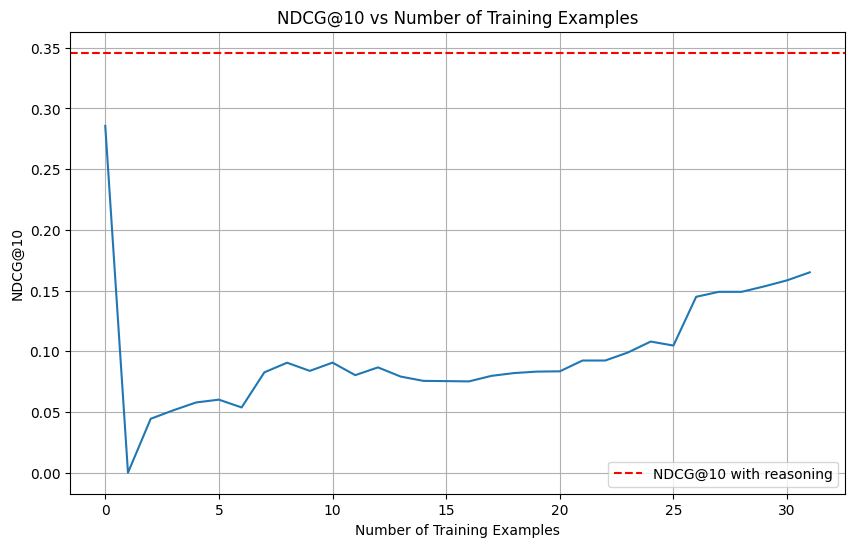

/tmp/ipykernel_1433496/583320236.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


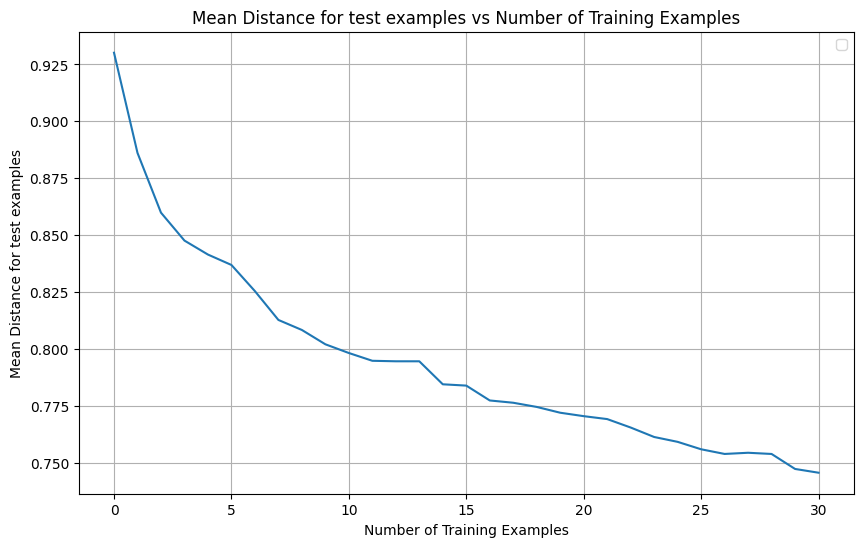

In [67]:
plot_val_vs_training_examples(
    ndcgs_at_10,
    name='NDCG@10',
    constant_val=res_without_proj_reason,
    constant_label='NDCG@10 with reasoning'
)
plot_val_vs_training_examples(mean_ds, 'Mean Distance for test examples')
